<a href="https://colab.research.google.com/github/IrisCheon/NLP-practice/blob/main/AI_News_Analysis_Tracking_Changes_in_AI_Discourse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#AI News Analysis: Tracking Changes in AI Discourse

- Questions
    - MIT의 AI기사 주제는 연도별/era별로 어떻게 변화했는가?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
base_path = r'/content/drive/MyDrive/1. data/dataset'
file_path = os.path.join(base_path, 'articles.csv')
df = pd.read_csv(file_path)

df.head()

,Unnamed: 0,Published Date,Author,Source,Article Header,Sub_Headings,Article Body,Url
0,0,"July 7, 2023",Adam Zewe,MIT News Office,Learning the language of molecules to predict ...,This AI system only needs a small amount of da...,['Discovering new materials and drugs typicall...,https://news.mit.edu/2023/learning-language-mo...
1,1,"July 6, 2023",Alex Ouyang,Abdul Latif Jameel Clinic for Machine Learning...,MIT scientists build a system that can generat...,"BioAutoMATED, an open-source, automated machin...",['Is it possible to build machine-learning mod...,https://news.mit.edu/2023/bioautomated-open-so...
2,2,"June 30, 2023",Jennifer Michalowski,McGovern Institute for Brain Research,"When computer vision works more like a brain, ...",Training artificial neural networks with data ...,"['From cameras to self-driving cars, many of t...",https://news.mit.edu/2023/when-computer-vision...
3,3,"June 30, 2023",Mary Beth Gallagher,School of Engineering,Educating national security leaders on artific...,"Experts from MIT’s School of Engineering, Schw...",['Understanding artificial intelligence and ho...,https://news.mit.edu/2023/educating-national-s...
4,4,"June 30, 2023",Adam Zewe,MIT News Office,Researchers teach an AI to write better chart ...,A new dataset can help scientists develop auto...,['Chart captions that explain complex trends a...,https://news.mit.edu/2023/researchers-chart-ca...


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1018 entries, 0 to 1017
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Unnamed: 0      1018 non-null   int64 
 1   Published Date  1018 non-null   object
 2   Author          848 non-null    object
 3   Source          832 non-null    object
 4   Article Header  1018 non-null   object
 5   Sub_Headings    870 non-null    object
 6   Article Body    1018 non-null   object
 7   Url             1018 non-null   object
dtypes: int64(1), object(7)
memory usage: 63.8+ KB


In [5]:
df.columns

Index(['Unnamed: 0', 'Published Date', 'Author', 'Source', 'Article Header',
       'Sub_Headings', 'Article Body', 'Url'],
      dtype='object')

In [8]:
df["date"] = pd.to_datetime(df["Published Date"])
df["year"] = df["date"].dt.year

df.head()

,Unnamed: 0,Published Date,Author,Source,Article Header,Sub_Headings,Article Body,Url,date,year
0,0,"July 7, 2023",Adam Zewe,MIT News Office,Learning the language of molecules to predict ...,This AI system only needs a small amount of da...,['Discovering new materials and drugs typicall...,https://news.mit.edu/2023/learning-language-mo...,2023-07-07,2023
1,1,"July 6, 2023",Alex Ouyang,Abdul Latif Jameel Clinic for Machine Learning...,MIT scientists build a system that can generat...,"BioAutoMATED, an open-source, automated machin...",['Is it possible to build machine-learning mod...,https://news.mit.edu/2023/bioautomated-open-so...,2023-07-06,2023
2,2,"June 30, 2023",Jennifer Michalowski,McGovern Institute for Brain Research,"When computer vision works more like a brain, ...",Training artificial neural networks with data ...,"['From cameras to self-driving cars, many of t...",https://news.mit.edu/2023/when-computer-vision...,2023-06-30,2023
3,3,"June 30, 2023",Mary Beth Gallagher,School of Engineering,Educating national security leaders on artific...,"Experts from MIT’s School of Engineering, Schw...",['Understanding artificial intelligence and ho...,https://news.mit.edu/2023/educating-national-s...,2023-06-30,2023
4,4,"June 30, 2023",Adam Zewe,MIT News Office,Researchers teach an AI to write better chart ...,A new dataset can help scientists develop auto...,['Chart captions that explain complex trends a...,https://news.mit.edu/2023/researchers-chart-ca...,2023-06-30,2023


#■ 연도 / 시대 구분

In [10]:
year_counts = df.groupby("year").size()
year_counts

,0
year,
1994,9
1995,5
1996,3
1997,10
1998,15
1999,9
2000,16
2001,6
2002,11


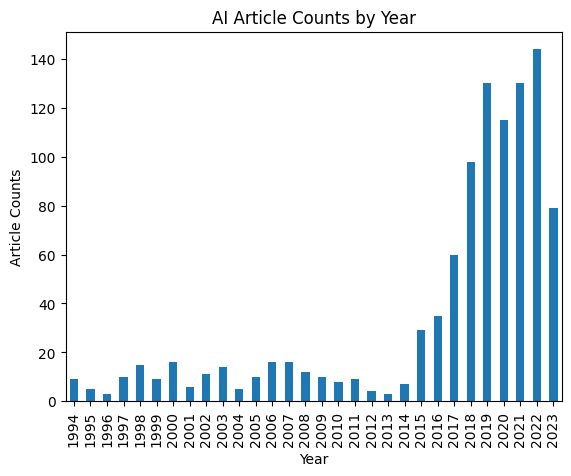

In [14]:
year_counts.plot(kind = "bar")
plt.title("AI Article Counts by Year")
plt.xlabel("Year")
plt.ylabel("Article Counts")
plt.show()

In [40]:
def assign_era(year):
    if year <= 1999 :
        return "-1990"
    elif year <= 2009 :
        return "2000-2009"
    elif year <= 2014 :
        return "2010-2014"
    elif year <= 2019 :
        return "2015-2019"
    else:
        return "2020-"

In [41]:
df["era"] = df["year"].apply(assign_era)
df["era"].value_counts()

,count
era,
2020-,468
2015-2019,352
2000-2009,116
-1990,51
2010-2014,31


#■ Text Length

In [18]:
df.columns

Index(['Unnamed: 0', 'Published Date', 'Author', 'Source', 'Article Header',
       'Sub_Headings', 'Article Body', 'Url', 'date', 'year', 'era'],
      dtype='object')

In [25]:
df["text_length"] = (df["Article Body"].str.len())
df["text_length"].describe()

,text_length
count,1018.000000
mean,5253.174853
std,2780.058831
min,2.000000
25%,3077.500000
50%,5605.000000
75%,7212.250000
max,17333.000000


In [51]:
era_text_length = df.groupby("era")["text_length"].mean()
era_text_length

,text_length
era,
-1990,4773.392157
2000-2009,3558.956897
2010-2014,1364.935484
2015-2019,5157.832386
2020-,6054.658120


In [77]:
era_counts = df.groupby("era").size()
era_counts

,0
era,
-1990,51
2000-2009,116
2010-2014,31
2015-2019,352
2020-,468


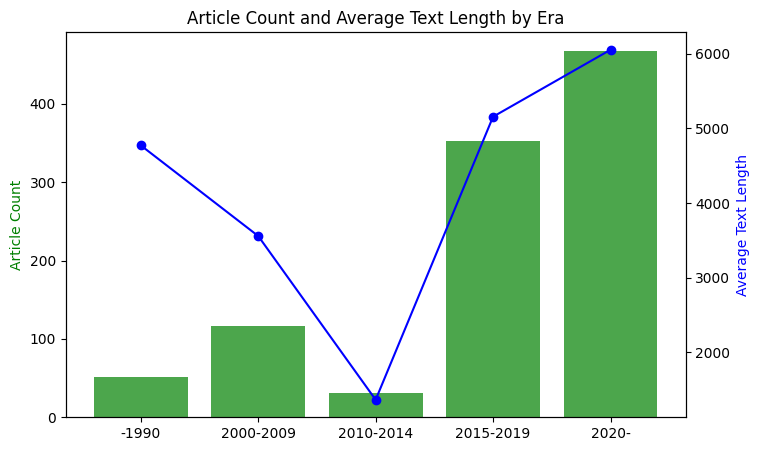

In [79]:
x = era_counts.index

fig, ax1 = plt.subplots(figsize=(8,5))

ax1.bar(
    x,
    era_counts.values,
    alpha=0.7,
    color = "green"
)

ax1.set_ylabel("Article Count", color = "green")

ax2 = ax1.twinx()

ax2.plot(
    x,
    era_text_length.values,
    marker="o",
    color = "blue"
)

ax2.set_ylabel("Average Text Length", color = "blue")

plt.title("Article Count and Average Text Length by Era")

plt.show()

- 1990년대 article 수는 적지만 텍스트의 길이는 길었음.
- 2000년-2014년까지는 데이터 수도 적고 텍스트 길이도 짧은 편
- 2015년부터 article 수가 급증하며 텍스트 길이도 증가
- 2020년대 article수도 많고(2020~2023의 4년치 데이터뿐임에도) text길이도 대폭 증가함.

# ■ TF-IDF

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [81]:
df["combined_text"] = df["Article Header"].fillna("") + " " + df["Sub_Headings"].fillna("") + " " + df["Article Body"]

In [82]:
df[["era", "combined_text"]].head()

,era,combined_text
0,2020-,Learning the language of molecules to predict ...
1,2020-,MIT scientists build a system that can generat...
2,2020-,"When computer vision works more like a brain, ..."
3,2020-,Educating national security leaders on artific...
4,2020-,Researchers teach an AI to write better chart ...


In [84]:
era_order = [
    "-1990",
    "2000-2009",
    "2010-2014",
    "2015-2019",
    "2020-"
]

In [83]:
def get_top_tfidf_words(texts, top_n=30):
    vectorizer = TfidfVectorizer(
        stop_words="english",
        min_df=3,
        max_df=0.8,
        ngram_range=(1, 2)
    )

    X = vectorizer.fit_transform(texts)

    mean_scores = np.asarray(X.mean(axis=0)).flatten()
    words = vectorizer.get_feature_names_out()

    tfidf_df = pd.DataFrame({
        "word": words,
        "tfidf_score": mean_scores
    })

    tfidf_df = tfidf_df.sort_values(
        "tfidf_score",
        ascending=False
    ).head(top_n)

    return tfidf_df

In [85]:
tfidf_by_era = {}

for era in era_order:
    era_texts = df.loc[
        df["era"] == era,
        "combined_text"
    ].dropna()

    top_words = get_top_tfidf_words(
        era_texts,
        top_n=30
    )

    tfidf_by_era[era] = top_words

In [86]:
tfidf_by_era["-1990"]

,word,tfidf_score
1540,robot,0.083235
1186,mr,0.056079
1568,robots,0.044719
1758,students,0.039897
2017,½ï,0.038689
2018,½ï ½ï,0.036454
1499,research,0.036362
1605,science,0.033812
95,ai,0.033661
468,design,0.033268


In [87]:
tfidf_by_era["2000-2009"]

,word,tfidf_score
2499,robot,0.050492
2558,said,0.049987
2522,robots,0.042712
976,engineering,0.039545
663,contest,0.037135
4,007,0.032520
625,computer,0.031638
1582,lab,0.030714
2937,team,0.030116
2448,research,0.029932


In [88]:
tfidf_by_era["2010-2014"]

,word,tfidf_score
85,mit,0.093007
120,robotic,0.087665
27,csail,0.077007
119,robot,0.070946
57,human,0.070787
122,robots,0.066938
20,computer,0.060068
62,intelligence,0.060049
6,algorithm,0.056306
121,robotics,0.055439


※ 2010-2014
- Artificial Intelligence 등장. 그러나 아직은 robot이 상위

In [89]:
tfidf_by_era["2015-2019"]

,word,tfidf_score
2151,data,0.036621
7718,says,0.033391
416,ai,0.032154
4928,learning,0.031199
1750,computer,0.029591
7436,researchers,0.028234
7374,research,0.027037
4428,intelligence,0.026754
5193,machine,0.025176
5659,model,0.024938


※ 2015-2019
- data가 상위로 급등. ai라는 약어를 더 많이 사용. machine learning 등장

In [90]:
tfidf_by_era["2020-"]

,word,tfidf_score
3130,data,0.038415
575,ai,0.038005
8316,model,0.035865
7200,learning,0.034704
8445,models,0.027735
11100,researchers,0.027099
7613,machine,0.024796
7616,machine learning,0.023741
11688,science,0.021168
2567,computer,0.019809


※ 2020-
- machine learning 관련(model 등)이 더 상위로

In [91]:
top_words_table = pd.DataFrame({
    era: tfidf_by_era[era]["word"].values
    for era in era_order
})

top_words_table.head(30)

,-1990,2000-2009,2010-2014,2015-2019,2020-
0,robot,robot,mit,data,data
1,mr,said,robotic,says,ai
2,robots,robots,csail,ai,model
3,students,engineering,robot,learning,learning
4,½ï,contest,human,computer,models
5,½ï ½ï,007,robots,researchers,researchers
6,research,computer,computer,research,machine
7,science,lab,intelligence,intelligence,machine learning
8,ai,team,algorithm,machine,science
9,design,research,robotics,model,computer


- data는 2010년대부터 급등하여 2015년부터는 계속 1위
- 2010년까지는 robot 등이 강세였음(physical?)
- ai는 1990년대에 8위였지만 2000-2010 사이에는 중요하게 다뤄지지 않음. 2010년에 다시 약어가 아닌 전체명칭으로 등장 > 2015년부터는 다시 ai로 주요하게 다뤄짐

# ■ Keyword Tracking

In [94]:
keywords = [
    "robot", "data", "ai", "machine", "job", "human", "computer"
]

In [95]:
for keyword in keywords:
    col_name = "has_" + keyword.replace(" ", "_")

    df[col_name] = df["combined_text"].str.contains(
        keyword,
        case = False,
        na = False,
        regex = False
    )

In [96]:
keyword_cols = [
    "has_" + keyword.replace(" ", "_")
    for keyword in keywords
]

era_keyword_rate = (
    df.groupby("era")[keyword_cols]
      .mean()
)

In [97]:
era_keyword_rate.columns = [
    col.replace("has_", "").replace("_", " ")
    for col in era_keyword_rate.columns
]

era_keyword_rate

,robot,data,ai,machine,job,human,computer
era,,,,,,,
-1990,0.843137,0.450980,1.000000,0.411765,0.039216,0.529412,0.823529
2000-2009,0.836207,0.155172,0.887931,0.525862,0.034483,0.439655,0.594828
2010-2014,0.451613,0.161290,0.580645,0.161290,0.000000,0.258065,0.419355
2015-2019,0.335227,0.613636,0.985795,0.659091,0.122159,0.568182,0.809659
2020-,0.252137,0.722222,0.993590,0.735043,0.151709,0.587607,0.709402


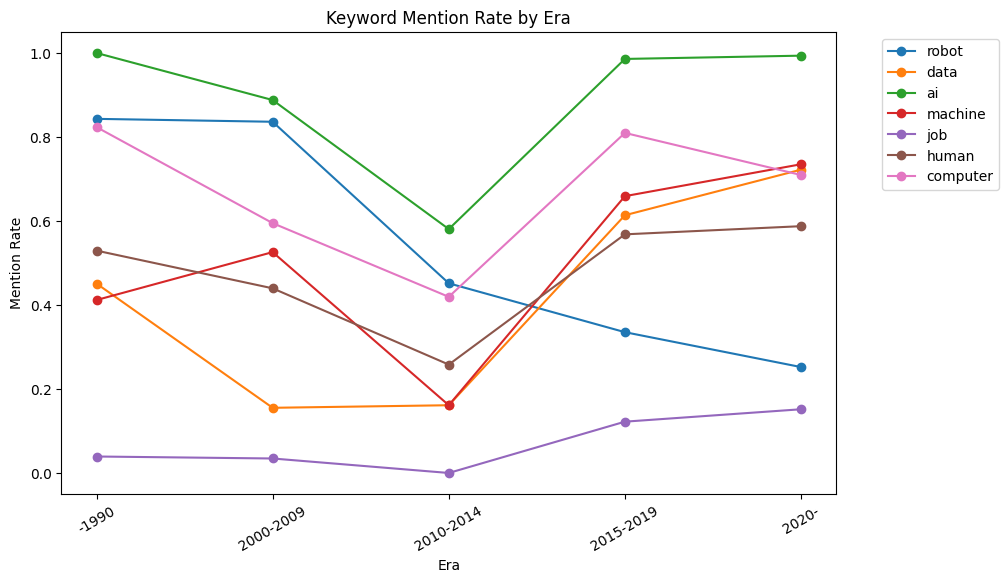

In [98]:
plt.figure(figsize=(10, 6))

for keyword in era_keyword_rate.columns:
    plt.plot(
        era_keyword_rate.index.astype(str),
        era_keyword_rate[keyword],
        marker="o",
        label=keyword
    )

plt.title("Keyword Mention Rate by Era")
plt.xlabel("Era")
plt.ylabel("Mention Rate")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=30)
plt.show()

- robot은 지속적인 하향세, data는 2009년까지 하향하가 2010년부터 상향세
- ai는 1990년에도 상위이다가, 2014년까지 하향. 그러다 이후 급 반등하여 최상위 중요도를 가짐
- computer, human, machine 등도 ai와 비슷한 추세를 보임.